# Analyse du sondage pôle N MineSabords

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme()

In [67]:
df = pd.read_csv("data/poll.csv")
df.head()

,Horodateur,Tu es en...,Les raisons pour lesquelles tu prends part à un évènement entreprise...,"Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [1]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [2]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [3]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [4]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [5]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [6]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [7]",...,Un domaine n'apparaissant pas dans la question précédente ?,"Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?\n( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )",Les types d'évènements que tu préfères...,Qu'espères-tu obtenir d'un évènement entreprise,Qu'elles sont les principales choses que tu veux savoir sur une entreprise ?,Une entreprise particulière que tu aimerais rencontrer ?,"Es-tu intéressé.e par la création d'un forum ""entreprises publiques"" ?","Es-tu intéressé.e par la mise en place d'un forum sur le secteur ""énergie et environnement"" ?",Es-tu intéressé.e par la mise en place d'un forum Start-up,Une dernière chose ? :)
0,2026/03/13 8:26:22 PM UTC+2,1A IC,la renommée de l'entreprise;le domaine d'activ...,Énergie et Environnement;Aéronautique;Économie...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,les amphis entreprises;les études de cas,NaN,NaN,NaN,Why not,oui,oui,NaN
1,2026/03/16 6:00:17 PM UTC+2,1A IC,le domaine d'activité de l'entreprise,Environnement,Énergie,Robotique et Automatisation,Économie et Finance,Transports,"Numérique, Informatique et IA",Santé et Biotechnologies,...,NaN,Recherche ou R&D,les amphis entreprises;les tables rondes;les v...,"Rencontrer des travailleurs, découvrir des ent...",Variété d'emplois,"Des services publics, CNRS, EDF, SNCF...",oui,oui,non,NaN
2,2026/03/16 6:21:59 PM UTC+2,1A IC,la présence d'un repas lors de l'évènement,Aéronautique,Mode et Luxe,Santé et Biotechnologies,"Numérique, Informatique et IA",Transports,Robotique et Automatisation,Environnement,...,Automobile,R&D,les amphis entreprises;les tables rondes,NaN,NaN,NaN,oui,oui,oui,NaN
3,2026/03/16 7:36:49 PM UTC+2,1A IC,la recherche d'un stage,Énergie,Environnement,Robotique et Automatisation,"Numérique, Informatique et IA",Aéronautique,Mode et Luxe,Économie et Finance,...,NaN,NaN,les études de cas,NaN,NaN,NaN,non,Non,oui,NaN
4,2026/03/17 10:58:03 AM UTC+2,1A IC,le domaine d'activité de l'entreprise,Aéronautique,Énergie,Santé et Biotechnologies,"Numérique, Informatique et IA",Robotique et Automatisation,Transports,Environnement,...,NaN,r et d,les tables rondes,NaN,NaN,NaN,oui,oui,oui,NaN


In [68]:
print("Nombre de réponses :", len(df))

Nombre de réponses : 112


### Répartition des votant.e.s par année d'étude

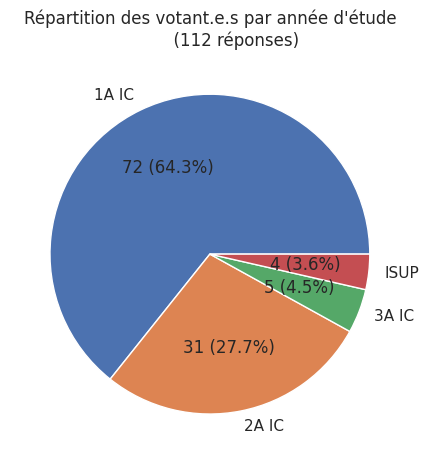

In [69]:
prom = df["Tu es en..."].value_counts()
total = prom.sum()

plt.pie(prom, labels=prom.index,
        autopct=lambda pct: f"{int(round(pct * total / 100.0))} ({pct:.1f}%)")

plt.title(f"""Répartition des votant.e.s par année d'étude
          ({len(df)} réponses)""")

plt.tight_layout()
plt.savefig("plots/prom.svg", bbox_inches="tight")
plt.savefig("plots/prom.pdf", bbox_inches="tight")
plt.show()

### Les raisons poussant à aller à un événement

In [70]:
reasons_data = df["Les raisons pour lesquelles tu prends part à un évènement entreprise..."].value_counts()

# each reason is separated by a semicolon
# so we need to split them and count them
reasons = {}
type_of_meal = {}

not_interested = ["J'y vais pas...",
                  "Je n'y ai jamais pris part",
                  "En vrai j’y participe pas"]

cocktail_lunch = ["La présence d'un repas lors de l'évènement",
                  "La présence d'un cocktail lors de l'évènement"]

combined_label = "Présence d'un repas ou cocktail lors de l'évènement"
cocktail_count = 0
meal_count = 0

for reason_list in reasons_data.index:
    count = reasons_data[reason_list]

    meal_already_counted = False

    for reason in reason_list.split(";"):
        reason = reason.strip().lower().capitalize()

        if reason in not_interested:
            reason = "Jamais pris part à un événement"

        if reason in cocktail_lunch :
            if reason == "La présence d'un cocktail lors de l'évènement":
                cocktail_count += count
                
            else:
                meal_count += count

            if not meal_already_counted :
                reason = combined_label
                meal_already_counted = True

            else:
                continue

        if reason not in reasons:
            reasons[reason] = 0

        reasons[reason] += count

print(reasons)
print(f"{combined_label} -> cocktail: {cocktail_count}, repas: {meal_count}")

{"La renommée de l'entreprise": 54, "Le domaine d'activité de l'entreprise": 93, "La recherche d'un stage": 48, "Présence d'un repas ou cocktail lors de l'évènement": 75, "La politique éthique de l'entreprise": 45, "Le fait de ne pas connaître l'entreprise présentée": 30, "Donner de l'argent au bde": 1, 'Jamais pris part à un événement': 3}
Présence d'un repas ou cocktail lors de l'évènement -> cocktail: 38, repas: 75


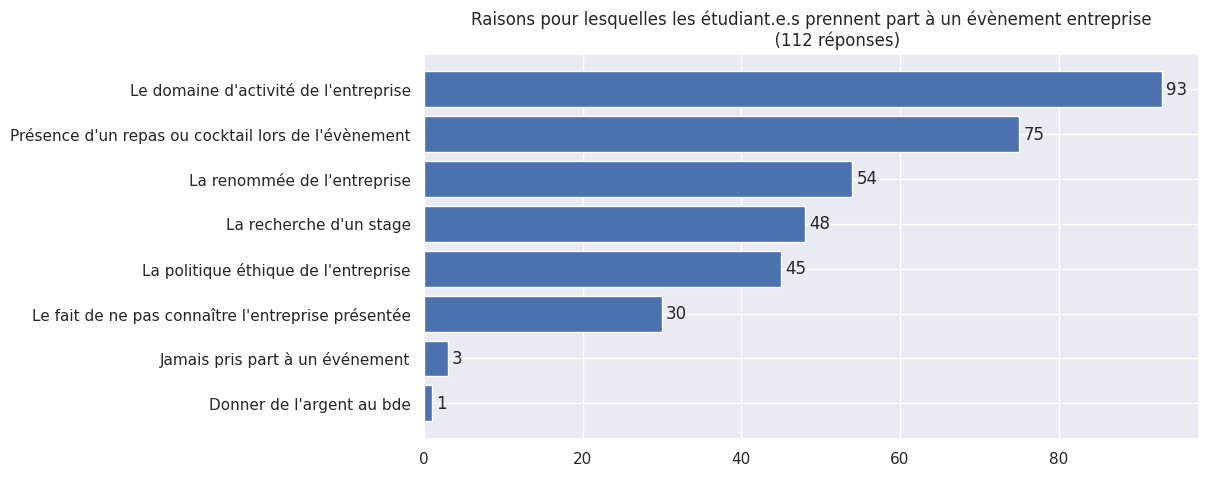

In [71]:
reasons = dict(sorted(reasons.items(), key=lambda item: item[1]))

labels = list(reasons.keys())

plt.figure(figsize=(10, 5))

bars = plt.barh(labels, list(reasons.values()))
plt.bar_label(bars, padding=3)

plt.title(f"""Raisons pour lesquelles les étudiant.e.s prennent part à un évènement entreprise
          ({len(df)} réponses)""")

plt.savefig("plots/reasons.svg", bbox_inches="tight")
plt.savefig("plots/reasons.pdf", bbox_inches="tight")
plt.show()

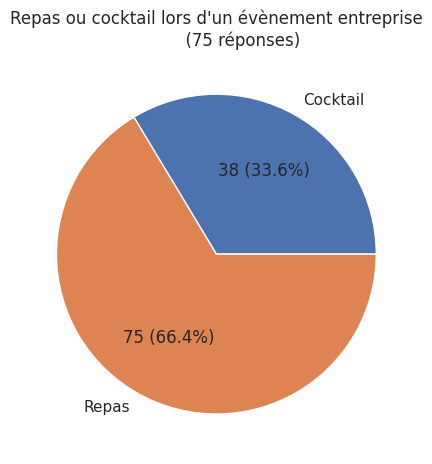

In [72]:
total = cocktail_count + meal_count
amount_voters = reasons[combined_label]

plt.pie([cocktail_count, meal_count], labels=["Cocktail", "Repas"],
        autopct=lambda pct: f"{int(round(pct * total / 100.0))} ({pct:.1f}%)")

plt.title(f"""Repas ou cocktail lors d'un évènement entreprise
          ({amount_voters} réponses)""")

plt.tight_layout()
plt.savefig("plots/meal_cocktail.svg", bbox_inches="tight")
plt.savefig("plots/meal_cocktail.pdf", bbox_inches="tight")
plt.show()

## Les domaines attirant le plus

Sur cette question, on demandait aux votant.e.s de noter les différents domaines proposés en fonction de leur intérêt.

In [73]:
question_prefix = "Les domaines d'activités qui t'intéressent le plus"
question_cols = [col for col in df.columns if col.startswith(question_prefix)]

ranked_domains = df[question_cols].copy()
max_rank = len(question_cols)

records = []
rows = ranked_domains.values.tolist()

for row in rows:
    for col_idx in range(max_rank):
        value = row[col_idx]
        if pd.isna(value):
            continue

        parts = [part.strip() for part in str(value).split(";") if part.strip()]
        if not parts:
            continue

        expanded_parts = []
        for part in parts:
            # Patch due to an old version of the survey
            # (Only 2 cases in the dataset, so we can do it manually)
            if part == "Énergie et Environnement":
                expanded_parts.extend(["Énergie", "Environnement"])
            else:
                expanded_parts.append(part)

        # Rank 1..9 according to columns [1]..[9].
        current_rank = col_idx + 1

        # If several domains are stored in one cell, distribute them
        # across following ranks to avoid a merged category.
        for domain in expanded_parts:
            if current_rank > max_rank:
                break

            records.append({
                "rank": current_rank,
                "domain": domain,
                "points": 10 - current_rank,
            })
            current_rank += 1

stats = {}
for record in records:
    domain = record["domain"]
    rank = record["rank"]
    points = record["points"]

    if domain not in stats:
        stats[domain] = {
            "total_score": 0,
            "rank_sum": 0,
            "mention_count": 0,
            "top1_count": 0,
        }

    stats[domain]["total_score"] += points
    stats[domain]["rank_sum"] += rank
    stats[domain]["mention_count"] += 1
    if rank == 1:
        stats[domain]["top1_count"] += 1

domain_rows = []
for domain, values in stats.items():
    domain_rows.append({
        "domain": domain,
        "total_score": values["total_score"],
        "average_rank": values["rank_sum"] / values["mention_count"],
        "mention_count": values["mention_count"],
        "top1_count": values["top1_count"],
    })

domain_stats = pd.DataFrame(domain_rows).set_index("domain")
domain_stats = domain_stats.sort_values(["total_score", "top1_count", "mention_count"], ascending=False)

n_domain_responses = int(ranked_domains.notna().any(axis=1).sum())
domain_stats.head(10)

,total_score,average_rank,mention_count,top1_count
domain,,,,
Énergie,807,3.330579,121,30
Environnement,675,3.918919,111,22
Transports,587,4.614679,109,8
Aéronautique,566,4.991150,113,13
Robotique et Automatisation,560,4.954955,111,6
"Numérique, Informatique et IA",557,4.842593,108,14
Santé et Biotechnologies,534,5.145455,110,8
Économie et Finance,471,5.718182,110,8
Mode et Luxe,268,7.563636,110,3


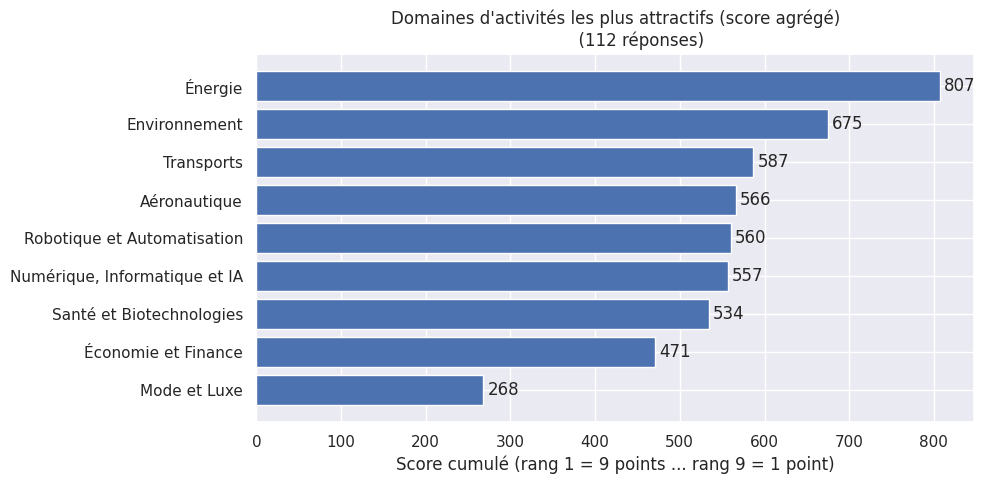

In [74]:
plot_data = domain_stats.sort_values("total_score", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(plot_data.index, plot_data["total_score"])
plt.bar_label(bars, padding=3)

plt.title(f"""Domaines d'activités les plus attractifs (score agrégé)
          ({n_domain_responses} réponses)""")
plt.xlabel("Score cumulé (rang 1 = 9 points ... rang 9 = 1 point)")

plt.tight_layout()
plt.savefig("plots/domains_score.svg", bbox_inches="tight")
plt.savefig("plots/domains_score.pdf", bbox_inches="tight")
plt.show()

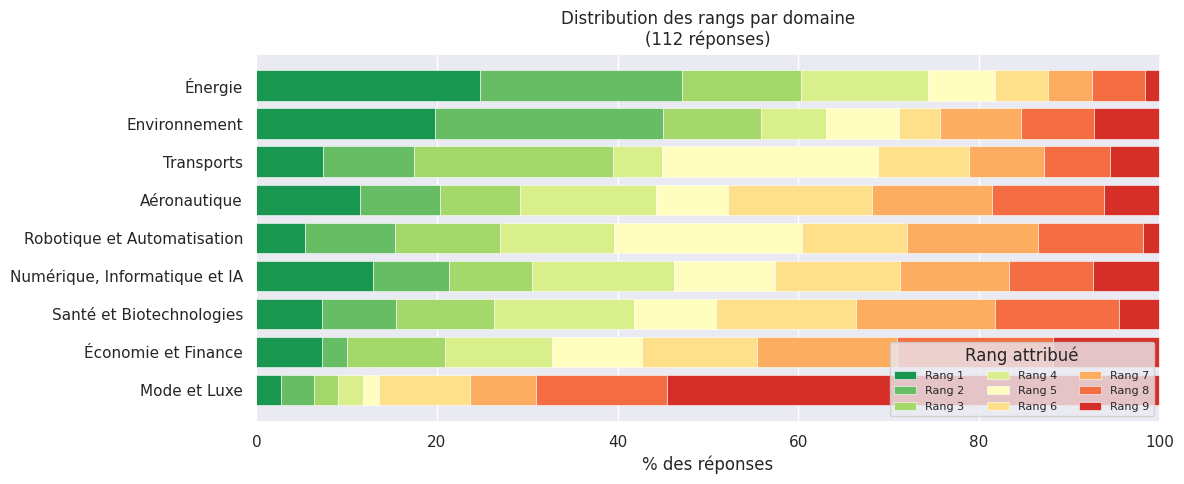

In [75]:
# Rank distribution: how often each domain was ranked 1st, 2nd, …9th
rank_matrix = {}
for record in records:
    d = record["domain"]
    r = record["rank"]
    rank_matrix.setdefault(d, {})[r] = rank_matrix.get(d, {}).get(r, 0) + 1

all_ranks = list(range(1, max_rank + 1))
domains_ordered = domain_stats.sort_values("total_score", ascending=True).index.tolist()

# Build a 2-D array: domains (rows) x ranks (cols), normalised to %
matrix = np.zeros((len(domains_ordered), len(all_ranks)))

for i, d in enumerate(domains_ordered):
    total = sum(rank_matrix.get(d, {}).values())
    for j, r in enumerate(all_ranks):
        matrix[i, j] = rank_matrix.get(d, {}).get(r, 0) / total * 100 if total else 0

# Diverging colormap, green for top ranks, red for bottom ranks
cmap = plt.get_cmap("RdYlGn_r")
rank_colors = [cmap(r / (max_rank + 1)) for r in all_ranks]

fig, ax = plt.subplots(figsize=(12, 5))
lefts = np.zeros(len(domains_ordered))
for j, r in enumerate(all_ranks):
    ax.barh(domains_ordered,
            matrix[:, j],
            left=lefts,
            color=rank_colors[j],
            label=f"Rang {r}",
            edgecolor="white",
            linewidth=0.4,)
    lefts += matrix[:, j]

ax.set_xlabel("% des réponses")
ax.set_title(f"Distribution des rangs par domaine\n"
             f"({n_domain_responses} réponses)")

ax.set_xlim(0, 100)
ax.legend(
    title="Rang attribué",
    loc="lower right",
    ncol=3,
    fontsize=8,
)

plt.tight_layout()
plt.savefig("plots/domains_rank_distribution.svg", bbox_inches="tight")
plt.savefig("plots/domains_rank_distribution.pdf", bbox_inches="tight")
plt.show()


### Autres domaines proposés

In [76]:
other_domains = df["Un domaine n'apparaissant pas dans la question précédente ?"]
other_domains = other_domains.dropna().str.strip()
other_domains

2                                             Automobile
9                                            La défense.
13                                          Construction
17                                               Conseil
19                              jeu vidéo/divertissement
25     L'action publique/sociale mais bon comme iels ...
30                                           La low tech
37                                Organisme de recherche
40                             la fonction publique !!!!
41                                            Logistique
42                                    Défense / armement
48                                              Sécurité
49                                    Recherche/physique
54                                           Aérospatial
61            Recherche ( je sais pas si c'est possible)
63                                               Conseil
71                     Génie Civil, BTP, Génie mécanique
72                             

## Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?
( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )

In [77]:
job_type = df["Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?\n( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )"]
job_type = job_type.dropna().str.strip()
job_type

1                                       Recherche ou R&D
2                                                    R&D
4                                                 r et d
13                                            Ingéniérie
16                                                   R&D
21                                                   R&D
22                                     R et D ou conseil
23     R&D !!! Et stratégie (surtout dans des grands ...
24               Service financier et analyse économique
29                R&D et Tech surtout (ML, data science)
32                                  R&D, Recherche fonda
33                      Charge d’affaires et de projets.
35     Technique (gestion de projet mais proche des t...
36                                recherche fondamentale
37                                recherche fondamentale
40               Recherche et developpement, le publique
41                                     Conseil, services
43                             

### Regroupement des fonctions par catégorie

In [78]:
job_type_col = "Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?\n( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )"
raw_responses = df[job_type_col].dropna().str.strip()

# Mapping: catégories avec mots-clés (en minuscule pour la comparaison)
# Ordonnées par spécificité décroissante pour éviter les faux positifs
categories_mapping = {
    "R&D": ["r&d", "r et d", "rnd", "r and d"],
    "Recherche fondamentale": ["recherche fondamentale", "recherche fonda", "physique fondamentale", "astrophysique"],
    "Recherche (générale)": ["recherche"],
    "Conseil / Stratégie": ["conseil", "stratégie", "politiques publiques"],
    "Gestion de projet": ["gestion de projet", "charge d", "manager", "management"],
    "Ingénierie / Technique": ["ingéniérie", "ingénierie", "technique", "bureaux d'étude", "métiers scientifiques"],
    "Data / IA / ML": ["data science", "ml", "données", " ia"],
    "Finance / Économie": ["financier", "économique", "finance"],
    "Fonction publique": ["fonction publique"],
}

category_counts = {cat: 0 for cat in categories_mapping.keys()}
uncategorized = []

for response in raw_responses:
    response_lower = response.lower()
    found_any = False

    for category, keywords in categories_mapping.items():
        for keyword in keywords:
            if keyword in response_lower:
                category_counts[category] += 1
                found_any = True
                break

    if not found_any:
        uncategorized.append(response)

print(f"=== UNCATEGORIZED ANSWERS ({len(uncategorized)}) ===")
for resp in sorted(uncategorized):
    print(f"  - {resp}")

=== UNCATEGORIZED ANSWERS (2) ===
  - Métiers pluridisciplinaires à l’interface de plusieurs métiers
  - tous les métiers dans l’aéronautique


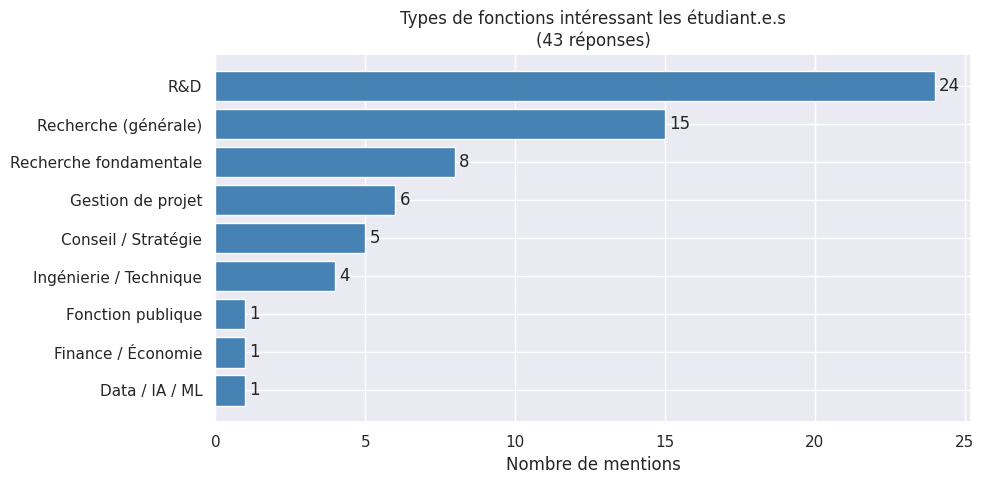

In [79]:
plot_data = sorted(category_counts.items(), key=lambda x: x[1])
labels = [x[0] for x in plot_data]
values = [x[1] for x in plot_data]

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, values, color='steelblue')
plt.bar_label(bars, padding=3)

plt.title(f"Types de fonctions intéressant les étudiant.e.s\n({len(raw_responses)} réponses)")
plt.xlabel("Nombre de mentions")

plt.tight_layout()
plt.savefig("plots/job_functions.svg", bbox_inches="tight")
plt.savefig("plots/job_functions.pdf", bbox_inches="tight")
plt.show()

## Qu'espères-tu obtenir d'un évènement entreprise ?

Uncategorized event type: 'Tant qu’il y a a manger'
Uncategorized event type: 'Amphi pizza'
Uncategorized event type: 'J'ai fait que des amphis'


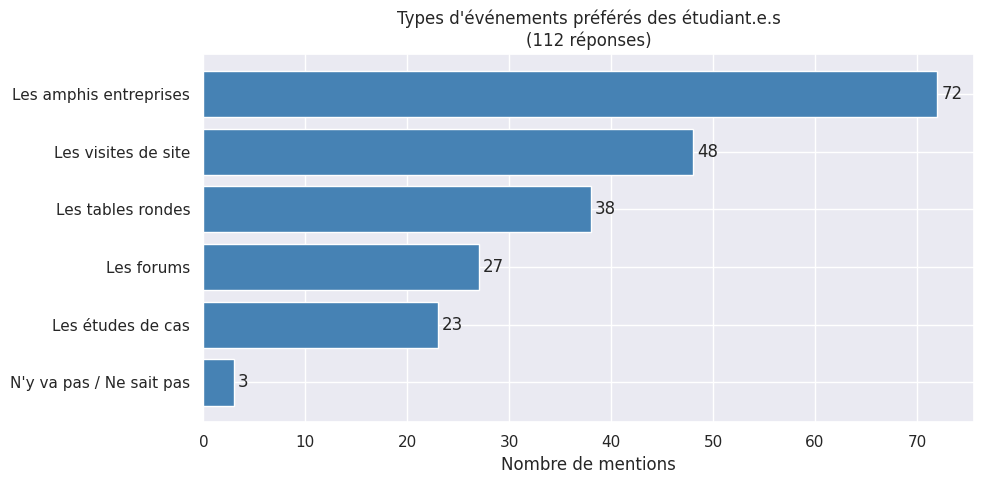

In [80]:
event_types_col = "Les types d'évènements que tu préfères..."
raw_event_types = df[event_types_col].dropna().str.strip()

event_types = {"Les amphis entreprises": 0,
               "Les visites de site": 0,
               "Les tables rondes": 0,
               "Les forums": 0,
               "Les études de cas": 0,
               "N'y va pas / Ne sait pas": 0}


for event_list in raw_event_types:
    for event_type in event_list.split(";"):
        event_type = event_type.strip()

        if event_type:
            event_type = event_type.lower().capitalize()

            if len(event_type) < 3:
                # 1 answer is just "/", just skip it
                continue

            elif "pas" in event_type:
                # 3 answers concerned
                event_type = "N'y va pas / Ne sait pas"

            elif "bureau" in event_type :
                # 1 answer concerned
                event_type = "Les visites de site"
            
            if event_type in event_types.keys():
                event_types[event_type] = event_types.get(event_type, 0) + 1

            else :
                print(f"Uncategorized event type: '{event_type}'")

# Sort by count
event_types = dict(sorted(event_types.items(), key=lambda x: x[1]))

plot_data = event_types.items()
labels = [x[0] for x in plot_data]
values = [x[1] for x in plot_data]

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, values, color='steelblue')
plt.bar_label(bars, padding=3)

plt.title(f"Types d'événements préférés des étudiant.e.s\n({len(raw_event_types)} réponses)")
plt.xlabel("Nombre de mentions")

plt.tight_layout()
plt.savefig("plots/event_types.svg", bbox_inches="tight")
plt.savefig("plots/event_types.pdf", bbox_inches="tight")
plt.show()

## Catégorisation des attentes lors d'événements entreprises

=== UNCATEGORIZED ANSWERS (2) ===
  - Connaître les entreprises que je ne connais pas + Savoir si elles sont éthiques
  - Un témoignage


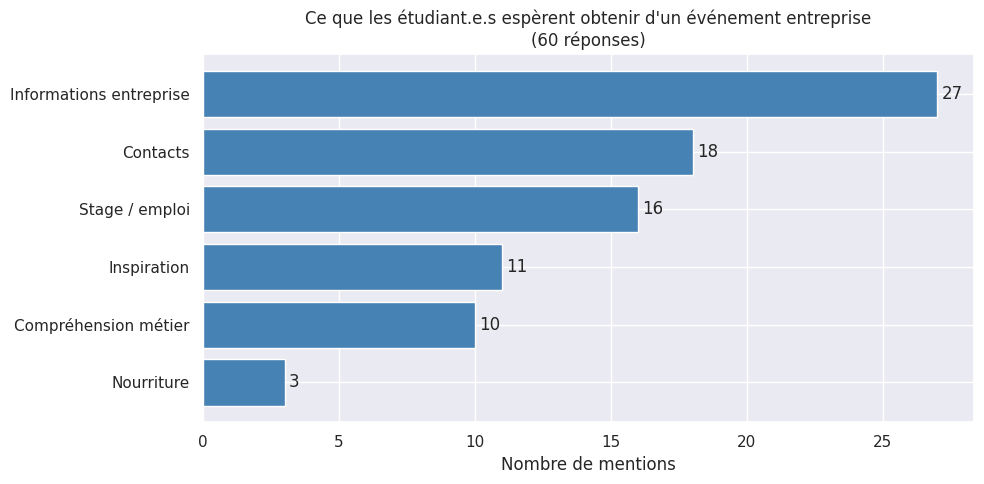

In [81]:
hopes_col = "Qu'espères-tu obtenir d'un évènement entreprise"
raw_hopes = df[hopes_col].dropna().str.strip()

# Mapping for categorizing hopes
hopes_categories = {
    "Contacts": ["contact", "rencontre"],
    "Informations entreprise": ["information", "info", "connaissance", "tâches", "fait", "mieux connaître", "postes"],
    "Stage / emploi": ["stage", "opportunité d'emploi", "offre d'emploi"],
    "Nourriture": ["pizza", "repas", "cocktail"],
    "Compréhension métier": ["métier", "fonction", "métiers", "job"],
    "Inspiration": ["inspiration", "inspiré", "curiosité", "envie", "découvrir"],
}

category_counts_hopes = {cat: 0 for cat in hopes_categories.keys()}
uncategorized_hopes = []

for response in raw_hopes:
    response_lower = response.lower()
    found_any = False

    for category, keywords in hopes_categories.items():
        for keyword in keywords:
            if keyword in response_lower:
                category_counts_hopes[category] += 1
                found_any = True
                break

    if not found_any:
        uncategorized_hopes.append(response)

print(f"=== UNCATEGORIZED ANSWERS ({len(uncategorized_hopes)}) ===")
for resp in sorted(uncategorized_hopes):
    print(f"  - {resp}")

# Plot
plot_data = sorted(category_counts_hopes.items(), key=lambda x: x[1])
labels = [x[0] for x in plot_data]
values = [x[1] for x in plot_data]

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, values, color='steelblue')
plt.bar_label(bars, padding=3)

plt.title(f"Ce que les étudiant.e.s espèrent obtenir d'un événement entreprise\n({len(raw_hopes)} réponses)")
plt.xlabel("Nombre de mentions")

plt.tight_layout()
plt.savefig("plots/hopes_categories.svg", bbox_inches="tight")
plt.savefig("plots/hopes_categories.pdf", bbox_inches="tight")
plt.show()

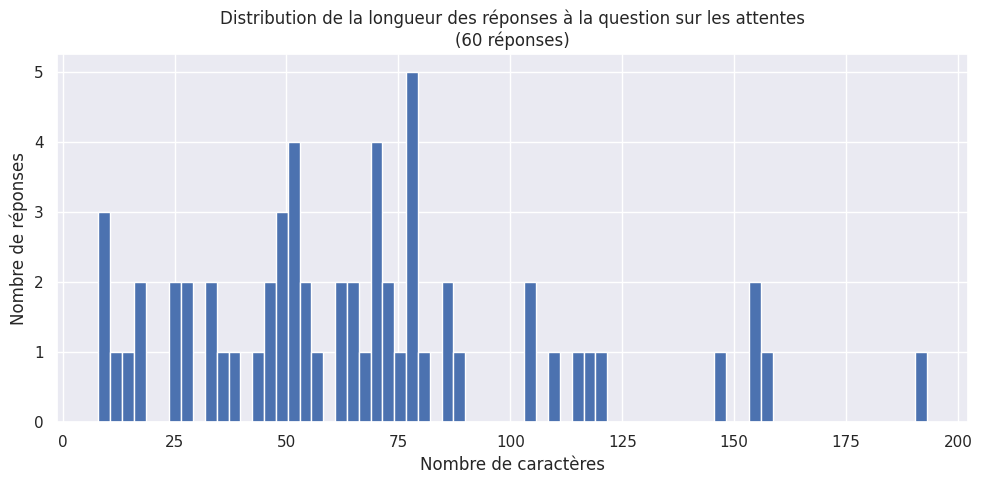

In [82]:
hopes_lengths = raw_hopes.apply(len)

plt.figure(figsize=(10, 5))
plt.hist(hopes_lengths, bins=70)
plt.title(f"Distribution de la longueur des réponses à la question sur les attentes\n({len(raw_hopes)} réponses)")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de réponses")
plt.tight_layout()
plt.savefig("plots/hopes_length_distribution.svg", bbox_inches="tight")
plt.savefig("plots/hopes_length_distribution.pdf", bbox_inches="tight")
plt.show()

On remarque que la longueur des réponses est très variable, mais on peut estimer que les réponses ayant plus de 50 caractères peuvent se distinguer par une plus grande précision et une plus grande richesse d'information.

In [83]:
n = 50
longest_hopes = raw_hopes[hopes_lengths >= n].sort_values(key=lambda x: x.str.len(),
                                                          ascending=False)

print(f"=== HOPES LONGS (>= {n} caractères) ({len(longest_hopes)}) ===")

for hope in longest_hopes:
    print(f"  - {hope}")

=== HOPES LONGS (>= 50 caractères) (39) ===
  - une bonne compréhension des enjeux financiers de l'entreprise et ... un stage (ie un employeur potentiel pas une boite à saturation qui te dit "postulez sur linkedin ou notre site" sans piston.
  - Avoir une idée plus précise de ce qu'on fait concrètement si on travaille chez eux. Quels métiers ils proposent et à quoi ressemble une semaine type chez eux.
  - Que fait l'entreprise (service et production, acteurs, marché etc) et quels postes ils proposent et qu'es ce qu'on y fait concrètement en temps qu'employé
  - Comprendre le métier des personnes invitées, ce qu’iels font de leur quotidien et qui sera peut être aussi le mien si je viens travailler dans leur équipe
  - Voir ce que font des gens qui sortent des Mines, discuter avec les intervenants (ou juste poser des questions), poser des questions sur les stages
  - De la culture et des informations sur l'entreprises afin de savoir si elle peut correspondre à mes projets et mes envies
 

## Principales choses à savoir sur une entreprise

In [84]:
company_info_col = "Qu'elles sont les principales choses que tu veux savoir sur une entreprise ?"
raw_company_info = df[company_info_col].dropna().str.strip()

# Mapping for categorizing what people want to know
company_info_categories = {
    "Emplois/Postes/Carrière": ["emploi", "poste", "carrière", "opportunité", "recrutement", "offre", "stage", "jobs", "évolution"],
    "Ambiance": ["ambiance", "culture"],
    "Salaire/Rémunération": ["salaire", "rémunération", "compensation", "financier"],
    "Conditions de travail, quotidien": ["conditions", "horaire", "télétravail", "flexibilité", "quotidien", "jour", "vie pro", "fonctionnement"],
    "Processus de recrutement": ["recrutement", "processus", "entretien", "sélection"],
    "Diversité/Inclusivité": ["diversité", "inclusivité", "inclusion", "parité", "mixité"],
    "Localisation": ["localisation", "localisation", "siège", "lieux", "pays", "étranger", "chez moi", "paris"],
    "Missions/Projets": ["mission", "projets", "projet"],
    "Éthique/Écologie": ["écologie", "environnement", "durabilité", "green", "éthique", "armes à israel", "environement", "valeur", "engagement"],
}

category_counts_info = {cat: 0 for cat in company_info_categories.keys()}
uncategorized_info = []

for response in raw_company_info:
    response_lower = response.lower()
    found_any = False

    for category, keywords in company_info_categories.items():
        for keyword in keywords:
            if keyword in response_lower:
                category_counts_info[category] += 1
                found_any = True
                break

    if not found_any:
        uncategorized_info.append(response)

print(f"=== UNCATEGORIZED ANSWERS ({len(uncategorized_info)}) ===")
for resp in sorted(uncategorized_info):
    print(f"  - {resp}")

=== UNCATEGORIZED ANSWERS (4) ===
  - (en général si les intervenants viennent de l'entreprises ils font marchands de tapis)
  - Qu'est ce qu'on peut faire en tant qu'ingénieur dans cette entreprise
  - domaine d’activité, stratégies futures et actuelles, concurrents et comment ils trouvent des solutions
  - organisation sociale


In [85]:
print("=== EMPTY CATEGORIES ===")
for category, count in category_counts_info.items():
    if count == 0:
        print(f"  - {category}")

=== EMPTY CATEGORIES ===
  - Diversité/Inclusivité


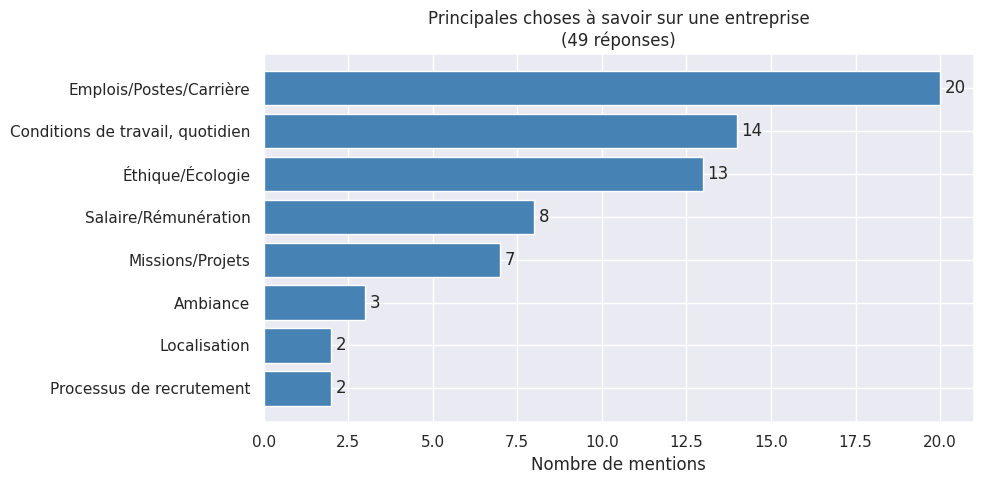

In [86]:
filtered_counts = {cat: count for cat,
                   count in category_counts_info.items() if count > 0}

plot_data = sorted(filtered_counts.items(), key=lambda x: x[1])
labels = [x[0] for x in plot_data]
values = [x[1] for x in plot_data]

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, values, color='steelblue')
plt.bar_label(bars, padding=3)

plt.title(
    f"Principales choses à savoir sur une entreprise\n({len(raw_company_info)} réponses)")
plt.xlabel("Nombre de mentions")

plt.tight_layout()
plt.savefig("plots/company_info.svg", bbox_inches="tight")
plt.savefig("plots/company_info.pdf", bbox_inches="tight")
plt.show()

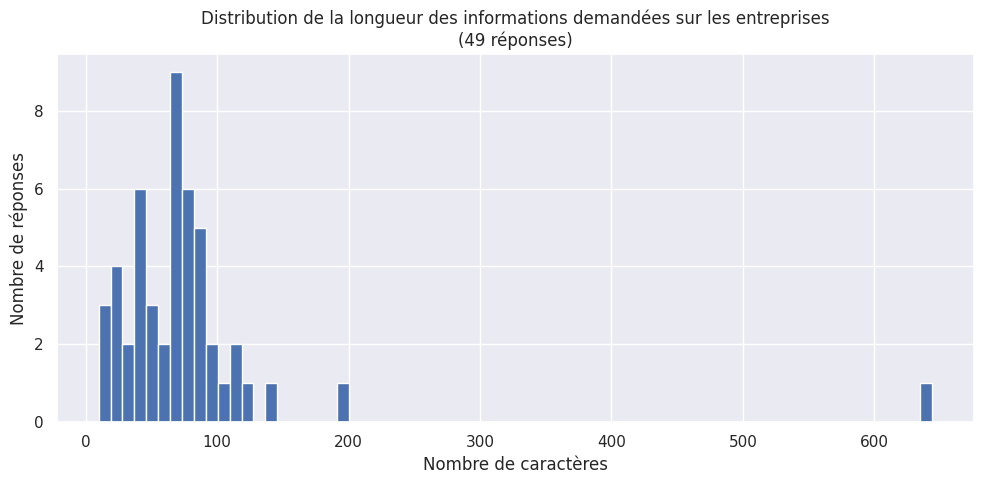

In [87]:
company_info_lengths = raw_company_info.apply(len)

plt.figure(figsize=(10, 5))
plt.hist(company_info_lengths, bins=70)
plt.title(f"Distribution de la longueur des informations demandées sur les entreprises\n({len(raw_company_info)} réponses)")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de réponses")
plt.tight_layout()
plt.savefig("plots/asked_info_length_distribution.svg", bbox_inches="tight")
plt.savefig("plots/asked_info_length_distribution.pdf", bbox_inches="tight")
plt.show()

On remarque que la longueur des réponses est très variable, mais on peut estimer que les réponses ayant plus de 50 caractères peuvent se distinguer par une plus grande précision et une plus grande richesse d'information.

In [88]:
n = 50
longest_asked_infos = raw_company_info[company_info_lengths >= n].sort_values(key=lambda x: x.str.len(),
                                                                              ascending=False)

print(f"=== ASKED INFOS LONGS (>= {n} caractères) ({len(longest_asked_infos)}) ===")

for info in longest_asked_infos:
    print(f"  - {info}")

=== ASKED INFOS LONGS (>= 50 caractères) (34) ===
  - J'aimerais juste que les gens qui viennent nous parler arrêtent de nous prendre pour des guignols en faisant du greenwashing à outrance. L'année dernière un employé présentait la stratégie verte de son entreprise et donnait les objectif à atteindre en 2025 (on devait être en novembre 2024). Respectueusement, je lui demande où en sont ces objectifs puisque l'ultimatum imposé approche, et on me baragouine une réponse pas satisfaisante du tout... 
Je sais que les politiques ne donnent pas vraiment l'exemple en matière de bullshit mais ptn on est des gens intelligents, faites usage de ça quoi !?
Désolé pour le pavé mais c'est important amha
  - - Quel impact l'entreprise juge-t-elle avoir sur le monde qui l'entoure.
- À quoi ça ressemble concrètement de travailler au sein de cette entreprise pour un poste donné (quotidien, missions,...)
  - Ses services et des choses concrètes comme comment se passe la fabrication du produit, à quoi res

## Intérêt pour les différents forums proposés

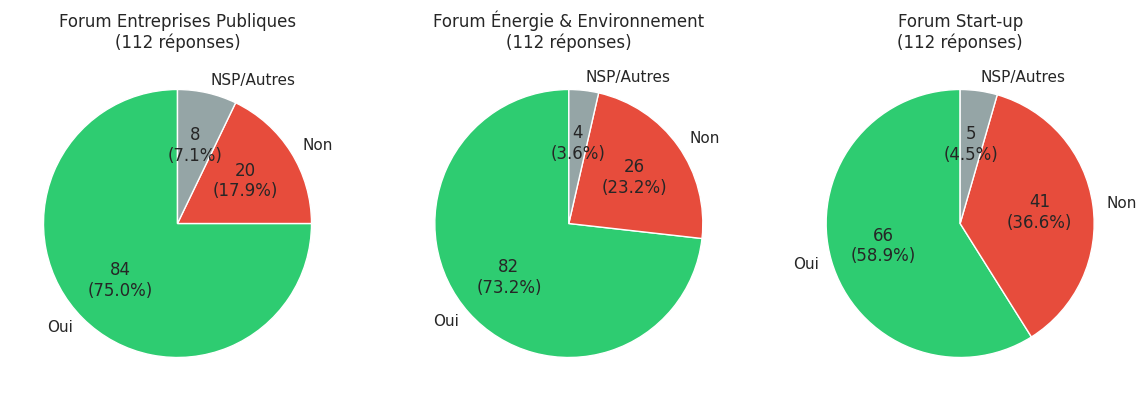

In [89]:
# Analyze the three forum questions
forum_cols = ["Es-tu intéressé.e par la création d'un forum \"entreprises publiques\" ? ",
              "Es-tu intéressé.e par la mise en place d'un forum sur le secteur \"énergie et environnement\" ? ",
              "Es-tu intéressé.e par la mise en place d'un forum Start-up"]

forum_names = ["Forum Entreprises Publiques",
               "Forum Énergie & Environnement",
               "Forum Start-up"]

other_answers = {"Forum Entreprises Publiques": [],
                 "Forum Énergie & Environnement": [],
                 "Forum Start-up": []}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, (col, name) in enumerate(zip(forum_cols, forum_names)):
    if col in df.columns:
        # Normalize responses (handle different casings)
        responses = df[col].dropna().str.strip().str.lower()
        
        # Count responses
        counts = responses.value_counts()
        
        # Normalize keys
        normalized_counts = {}
        for key, val in counts.items():
            if 'oui' in key or 'ouaaaaaaaaaaaaaaaaaaaaaais' in key or 'environnement' in key:
                normalized_counts['Oui'] = normalized_counts.get('Oui', 0) + val

            elif 'non' in key or 'bof' in key or 'pas plus que ça' in key:
                normalized_counts['Non'] = normalized_counts.get('Non', 0) + val

            else:
                # "why not" and other responses
                normalized_counts['NSP/Autres'] = normalized_counts.get('NSP/Autres', 0) + val
                other_answers[name].append(key)
        
        # Create pie chart
        colors = ['#2ecc71', '#e74c3c', '#95a5a6']
        wedges, texts, autotexts = axes[idx].pie(
            normalized_counts.values(),
            labels=normalized_counts.keys(),
            autopct=lambda pct: f"{int(round(pct * sum(normalized_counts.values()) / 100.0))}\n({pct:.1f}%)",
            colors=colors,
            startangle=90
        )
        
        axes[idx].set_title(f"""{name}
({sum(normalized_counts.values())} réponses)""")

plt.tight_layout()
plt.savefig("plots/forums_interest.svg", bbox_inches="tight")
plt.savefig("plots/forums_interest.pdf", bbox_inches="tight")
plt.show()

In [90]:
for key, val in other_answers.items():
    print(f'=== OTHER ANSWERS FOR "{key}" ({len(val)}) ===')
    
    for ans in val:
        print(f"  - {ans}")

    print("\n")

=== OTHER ANSWERS FOR "Forum Entreprises Publiques" (8) ===
  - why not
  - si ça remplasse d'autres amphis pourquoi pas, rajouter un évènement ne me parait pas être une bonne idée
  - je sais pas trop. pourquoi pas...
  - qu'est ce que vous entendez par "forum" ?
  - nsp
  - jsp
  - je sais pas
  - pas opposée


=== OTHER ANSWERS FOR "Forum Énergie & Environnement" (3) ===
  - jsp
  - same
  - nsp


=== OTHER ANSWERS FOR "Forum Start-up" (4) ===
  - pourquoi pas
  - pas d’avis
  - jsp
  - pas opposée




Remarque notifiée pour le forum environnement / énergie : "environnement au sens large, pas juste l'énergie"

## Remarques

In [91]:
additional_comments = df["Une dernière chose ? :)"].dropna().str.strip()
thanks_count = 0

print(f"=== ADDITIONAL COMMENTS ({len(additional_comments)}) ===")
for comment in additional_comments:
    if "merci" in comment.lower():
        thanks_count += 1

    print(f"  - {comment}")

=== ADDITIONAL COMMENTS (29) ===
  - PICHE Piche Piche.
  - Merci ❤️
  - Dream : Des entreprises énergétiques et des métiers terrains / ingéniérie ( stop la data/IA par pitié:) )
  - merci pour votre travail 🫶
  - Merciii
  - Branchez vous finance la team, plutôt que conseil. C'est bien plus stylé et skilled et ça correspond à nos profils malgré tout
  - Il suffit de voir les domaines pour comprendre que si vous voulez vraiment qu'environnementalement votre mandat se tienne, il faut réduire drastiquement les budgets. Mode, aéronautique, IA, finance... tout ça c'est juste aberrant socio-écologiquement parlant. En fait vous avez pas vraiment le choix puisque vous avez une certaine envie de faire les choses bien. Ou bien vous faites les choses à la marge en changeant pas foncièrement le système (donc vous allez chercher la "mode responsable", "la finance verte", les "carburants innovants" blablabla, c'est ce que les BDE font depuis qu'ils veulent avoir la conscience tranquille), ou alors 